# Dataset Setup

Load the battery cycle files and check the dataset structure.

In [3]:
from pathlib import Path

DATA_DIR = Path("/content")

parquet_files = sorted(DATA_DIR.glob("Qtzl_Cycle_*.parquet"))

# Expected number of cycle files.
EXPECTED_FILE_COUNT = 410

print("Total number of Parquet files:", len(parquet_files))
print("First file:", parquet_files[0].name)
print("Last file:", parquet_files[-1].name)

if len(parquet_files) == EXPECTED_FILE_COUNT:
    print("Dataset file count check: Passed")
else:
    print("Dataset file count check: Warning!")
    print(
        f"Expected {EXPECTED_FILE_COUNT} files, "
        f"but found {len(parquet_files)} files."
    )

Total number of Parquet files: 410
First file: Qtzl_Cycle_001_Capacity_check_partial_data.parquet
Last file: Qtzl_Cycle_410_WLTP.parquet
Dataset file count check: Passed


## Dataset Structure

Inspect the columns and check that all cycle files have the same structure.

In [4]:
import pyarrow.parquet as pq

sample_file = parquet_files[0]

parquet_file = pq.ParquetFile(sample_file)

column_names = parquet_file.schema.names

cell_voltage_columns = [
    column for column in column_names
    if column.startswith("Voltage_Cell_")
]

cell_temperature_columns = [
    column for column in column_names
    if column.startswith("Temperature_Cell_")
]

branch_current_columns = [
    column for column in column_names
    if column.startswith("Current_Actual_P")
]

# Required columns for the analysis.
required_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp",
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]"
]

missing_required_columns = [
    column for column in required_columns
    if column not in column_names
]

print("Sample file:", sample_file.name)
print("Number of rows:", parquet_file.metadata.num_rows)
print("Number of columns:", parquet_file.metadata.num_columns)
print("Number of cell voltage columns:", len(cell_voltage_columns))
print("Number of cell temperature columns:", len(cell_temperature_columns))
print("Number of branch current columns:", len(branch_current_columns))
print("Missing required columns:", missing_required_columns)

schema_check_passed = (
    parquet_file.metadata.num_columns == 132
    and len(cell_voltage_columns) == 36
    and len(cell_temperature_columns) == 72
    and len(branch_current_columns) == 3
    and len(missing_required_columns) == 0
)

if schema_check_passed:
    print("Dataset schema check: Passed")
else:
    print("Dataset schema check: Warning!")

Sample file: Qtzl_Cycle_001_Capacity_check_partial_data.parquet
Number of rows: 94362
Number of columns: 132
Number of cell voltage columns: 36
Number of cell temperature columns: 72
Number of branch current columns: 3
Missing required columns: []
Dataset schema check: Passed


In [5]:
reference_columns = parquet_file.schema.names

schema_issues = []

for file_path in parquet_files:
    current_file = pq.ParquetFile(file_path)
    current_columns = current_file.schema.names

    if current_columns != reference_columns:
        schema_issues.append({
            "file": file_path.name,
            "number_of_columns": current_file.metadata.num_columns,
            "missing_columns": sorted(set(reference_columns) - set(current_columns)),
            "extra_columns": sorted(set(current_columns) - set(reference_columns))
        })

print("Total files checked:", len(parquet_files))
print("Files with schema differences:", len(schema_issues))

if len(schema_issues) == 0:
    print("Schema consistency check: Passed")
else:
    print("Schema consistency check: Warning!")

    for issue in schema_issues[:10]:
        print("\nFile:", issue["file"])
        print("Number of columns:", issue["number_of_columns"])
        print("Missing columns:", issue["missing_columns"])
        print("Extra columns:", issue["extra_columns"])

Total files checked: 410
Files with schema differences: 0
Schema consistency check: Passed


# Data Quality Checks

Check missing values, timestamps, operating ranges and cycle structure before analysis.

In [6]:
import re
import gc
import pandas as pd

core_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp",
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]"
]

quality_records = []

for index, file_path in enumerate(parquet_files, start=1):

    # Read only the core columns to keep memory usage low.
    table = pq.read_table(file_path, columns=core_columns)
    df = table.to_pandas()

    file_match = re.search(r"Cycle_(\d+)", file_path.name)
    expected_cycle = int(file_match.group(1)) if file_match else None

    cycle_values = df["Cycle"].dropna().astype(str).unique()

    actual_cycle = None

    if len(cycle_values) == 1:
        cycle_match = re.search(r"(\d+)", cycle_values[0])

        if cycle_match:
            actual_cycle = int(cycle_match.group(1))

    cycle_number_matches = (
        expected_cycle is not None
        and actual_cycle is not None
        and actual_cycle == expected_cycle
    )

    timestamps = pd.to_datetime(
        df["Timestamp"],
        errors="coerce"
    )

    invalid_timestamp_count = int(timestamps.isna().sum())

    valid_timestamps = timestamps.dropna()

    timestamps_monotonic = (
        valid_timestamps.is_monotonic_increasing
        if len(valid_timestamps) > 0
        else False
    )

    missing_value_count = int(
        df[core_columns].isna().sum().sum()
    )

    semicycle_types = sorted(
        df["Semicycle"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    quality_records.append({
        "file_name": file_path.name,
        "expected_cycle": expected_cycle,
        "actual_cycle": actual_cycle,
        "cycle_number_matches": cycle_number_matches,
        "row_count": len(df),
        "start_timestamp": (
            valid_timestamps.min()
            if len(valid_timestamps) > 0
            else pd.NaT
        ),
        "end_timestamp": (
            valid_timestamps.max()
            if len(valid_timestamps) > 0
            else pd.NaT
        ),
        "timestamps_monotonic": timestamps_monotonic,
        "invalid_timestamp_count": invalid_timestamp_count,
        "missing_value_count_core_columns": missing_value_count,
        "semicycle_types": semicycle_types
    })

    # Release memory before processing the next file.
    del df
    del table
    gc.collect()

    if index % 50 == 0 or index == len(parquet_files):
        print(
            f"Processed {index} of "
            f"{len(parquet_files)} files"
        )

quality_summary = pd.DataFrame(quality_records)

Processed 50 of 410 files
Processed 100 of 410 files
Processed 150 of 410 files
Processed 200 of 410 files
Processed 250 of 410 files
Processed 300 of 410 files
Processed 350 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


In [7]:
all_semicycle_types = sorted({
    semicycle
    for semicycles in quality_summary["semicycle_types"]
    for semicycle in semicycles
})

print("Total files checked:", len(quality_summary))
print("Total rows across all files:", f"{quality_summary['row_count'].sum():,}")
print(
    "Files with cycle-number mismatches:",
    (~quality_summary["cycle_number_matches"]).sum()
)
print(
    "Files with non-monotonic timestamps:",
    (~quality_summary["timestamps_monotonic"]).sum()
)
print(
    "Files with invalid timestamps:",
    (quality_summary["invalid_timestamp_count"] > 0).sum()
)
print(
    "Files with missing values in core columns:",
    (quality_summary["missing_value_count_core_columns"] > 0).sum()
)
print("Earliest timestamp:", quality_summary["start_timestamp"].min())
print("Latest timestamp:", quality_summary["end_timestamp"].max())

print("\nObserved semicycle categories:")

for semicycle in all_semicycle_types:
    print("-", semicycle)

Total files checked: 410
Total rows across all files: 30,187,165
Files with cycle-number mismatches: 0
Files with non-monotonic timestamps: 0
Files with invalid timestamps: 0
Files with missing values in core columns: 0
Earliest timestamp: 2025-03-23 23:27:58.164157
Latest timestamp: 2025-09-03 18:37:15.680142

Observed semicycle categories:
- Balancing
- Capacity check Charge
- Capacity check Discharge
- Constant Charge
- Fast Charge
- Fast Discharge
- Stand by
- WLTP


In [8]:
sample_df = pd.read_parquet(parquet_files[0])

print("Sample file:", parquet_files[0].name)
print("Dataset shape:", sample_df.shape)

print("\nData type distribution:")
print(sample_df.dtypes.value_counts())

# Columns for a quick data preview.
preview_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp",
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]",
    "Voltage_Cell_P1S1 [V]",
    "Voltage_Cell_P2S1 [V]",
    "Voltage_Cell_P3S1 [V]",
    "Temperature_Cell_Top_P1S1 [degC]",
    "Temperature_Cell_Bottom_P1S1 [degC]"
]

print("\nSelected raw-data preview:")
display(sample_df[preview_columns].head(10))

Sample file: Qtzl_Cycle_001_Capacity_check_partial_data.parquet
Dataset shape: (94362, 132)

Data type distribution:
float32           127
object              2
float64             2
datetime64[us]      1
Name: count, dtype: int64

Selected raw-data preview:


,Cycle,Semicycle,Timestamp,Current_Actual_Battery [A],Voltage_Actual_Battery [V],SoC_Actual_Battery [percent],Voltage_Cell_P1S1 [V],Voltage_Cell_P2S1 [V],Voltage_Cell_P3S1 [V],Temperature_Cell_Top_P1S1 [degC],Temperature_Cell_Bottom_P1S1 [degC]
0,Cycle_1,Capacity check Discharge,2025-03-23 23:27:58.164157,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
1,Cycle_1,Capacity check Discharge,2025-03-23 23:27:58.563771,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
2,Cycle_1,Capacity check Discharge,2025-03-23 23:27:58.963749,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
3,Cycle_1,Capacity check Discharge,2025-03-23 23:27:59.353658,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
4,Cycle_1,Capacity check Discharge,2025-03-23 23:27:59.763877,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
5,Cycle_1,Capacity check Discharge,2025-03-23 23:28:00.154291,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
6,Cycle_1,Capacity check Discharge,2025-03-23 23:28:00.554302,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
7,Cycle_1,Capacity check Discharge,2025-03-23 23:28:00.963644,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
8,Cycle_1,Capacity check Discharge,2025-03-23 23:28:01.354341,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001
9,Cycle_1,Capacity check Discharge,2025-03-23 23:28:01.764197,0.0,50.200001,99.0,4.195,4.194,4.191,23.57,23.780001


In [9]:
# Cycle, Semicycle and Timestamp are identifiers,
# so the remaining 129 measurement columns are checked.
identifier_columns = [
    "Cycle",
    "Semicycle",
    "Timestamp"
]

measurement_columns = [
    column for column in reference_columns
    if column not in identifier_columns
]

missing_counts = pd.Series(
    0,
    index=measurement_columns,
    dtype="int64"
)

total_rows_checked = 0
files_with_missing_measurements = 0
file_missing_records = []

for index, file_path in enumerate(parquet_files, start=1):

    # Read one cycle at a time to limit memory use.
    table = pq.read_table(
        file_path,
        columns=measurement_columns
    )

    total_rows_checked += table.num_rows

    file_missing_counts = pd.Series({
        column: table[column].null_count
        for column in measurement_columns
    })

    total_file_missing = int(file_missing_counts.sum())

    missing_counts = (
        missing_counts
        .add(file_missing_counts, fill_value=0)
        .astype("int64")
    )

    if total_file_missing > 0:
        files_with_missing_measurements += 1

        file_missing_records.append({
            "file_name": file_path.name,
            "missing_values": total_file_missing,
            "columns_with_missing_values": int(
                (file_missing_counts > 0).sum()
            )
        })

    del table
    gc.collect()

    if index % 50 == 0 or index == len(parquet_files):
        print(f"Processed {index} of {len(parquet_files)} files")

missing_summary = pd.DataFrame({
    "column": measurement_columns,
    "missing_values": missing_counts.values
})

missing_summary["missing_percentage"] = (
    missing_summary["missing_values"]
    / total_rows_checked
    * 100
)

missing_summary = (
    missing_summary
    .sort_values("missing_values", ascending=False)
    .reset_index(drop=True)
)

file_missing_summary = pd.DataFrame(file_missing_records)

Processed 50 of 410 files
Processed 100 of 410 files
Processed 150 of 410 files
Processed 200 of 410 files
Processed 250 of 410 files
Processed 300 of 410 files
Processed 350 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


In [10]:
columns_with_missing_values = int(
    (missing_summary["missing_values"] > 0).sum()
)

total_missing_values = int(
    missing_summary["missing_values"].sum()
)

print("Total files checked:", len(parquet_files))
print("Total rows checked:", f"{total_rows_checked:,}")
print("Measurement columns checked:", len(measurement_columns))
print("Files with missing measurement values:", files_with_missing_measurements)
print("Measurement columns with missing values:", columns_with_missing_values)
print("Total missing measurement values:", f"{total_missing_values:,}")

if total_missing_values == 0:
    print("Full measurement missing-value check: Passed")
else:
    print("Full measurement missing-value check: Review Needed")

    print("\nTop columns with missing values:")

    display(
        missing_summary[
            missing_summary["missing_values"] > 0
        ].head(20)
    )

    print("\nFiles with the largest number of missing values:")

    display(
        file_missing_summary
        .sort_values("missing_values", ascending=False)
        .head(20)
    )

Total files checked: 410
Total rows checked: 30,187,165
Measurement columns checked: 129
Files with missing measurement values: 2
Measurement columns with missing values: 2
Total missing measurement values: 11,252
Full measurement missing-value check: Review Needed

Top columns with missing values:


,column,missing_values,missing_percentage
0,Voltage_Actual_Battery_IT5101 [V],5626,0.018637
1,Resistance_Actual_Battery_IT5101 [Ohm],5626,0.018637



Files with the largest number of missing values:


,file_name,missing_values,columns_with_missing_values
0,Qtzl_Cycle_026_Capacity_check_partial_data.par...,10720,2
1,Qtzl_Cycle_043_Capacity_check_partial_data.par...,532,2


The missing values were limited to two measurement columns that are not used in the modelling features, so they do not affect the subsequent analysis.

In [11]:
range_columns = [
    "Current_Actual_Battery [A]",
    "Voltage_Actual_Battery [V]",
    "SoC_Actual_Battery [percent]"
]

range_records = []
duplicate_timestamp_files = []

for index, file_path in enumerate(parquet_files, start=1):

    df = pd.read_parquet(
        file_path,
        columns=["Timestamp", *range_columns]
    )

    # Check duplicate timestamps within each cycle.
    duplicate_timestamps = int(
        df["Timestamp"].duplicated().sum()
    )

    if duplicate_timestamps > 0:
        duplicate_timestamp_files.append({
            "file_name": file_path.name,
            "duplicate_timestamps": duplicate_timestamps
        })

    range_records.append({
        "file_name": file_path.name,
        "current_min": df["Current_Actual_Battery [A]"].min(),
        "current_max": df["Current_Actual_Battery [A]"].max(),
        "voltage_min": df["Voltage_Actual_Battery [V]"].min(),
        "voltage_max": df["Voltage_Actual_Battery [V]"].max(),
        "soc_min": df["SoC_Actual_Battery [percent]"].min(),
        "soc_max": df["SoC_Actual_Battery [percent]"].max()
    })

    if index % 50 == 0 or index == len(parquet_files):
        print(f"Processed {index} of {len(parquet_files)} files")

range_summary = pd.DataFrame(range_records)
duplicate_timestamp_summary = pd.DataFrame(duplicate_timestamp_files)

Processed 50 of 410 files
Processed 100 of 410 files
Processed 150 of 410 files
Processed 200 of 410 files
Processed 250 of 410 files
Processed 300 of 410 files
Processed 350 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


In [12]:
print("Files with duplicate timestamps:", len(duplicate_timestamp_summary))
print("Overall minimum battery current [A]:", range_summary["current_min"].min())
print("Overall maximum battery current [A]:", range_summary["current_max"].max())
print("Overall minimum battery voltage [V]:", range_summary["voltage_min"].min())
print("Overall maximum battery voltage [V]:", range_summary["voltage_max"].max())
print("Overall minimum State of Charge [%]:", range_summary["soc_min"].min())
print("Overall maximum State of Charge [%]:", range_summary["soc_max"].max())

if len(duplicate_timestamp_summary) == 0:
    print("Duplicate timestamp check: Passed")
else:
    print("Duplicate timestamp check: Review Needed")
    display(duplicate_timestamp_summary.head(20))

Files with duplicate timestamps: 1
Overall minimum battery current [A]: -19.600000381469727
Overall maximum battery current [A]: 5.400000095367432
Overall minimum battery voltage [V]: 31.5
Overall maximum battery voltage [V]: 53.5
Overall minimum State of Charge [%]: 0.0
Overall maximum State of Charge [%]: 100.0
Duplicate timestamp check: Review Needed


,file_name,duplicate_timestamps
0,Qtzl_Cycle_168_WLTP.parquet,28


### Duplicate Timestamp Check

Cycle 168 contained 28 repeated timestamps in Balancing and Stand by, but no exact duplicate rows were found. The repeated timestamps were outside the WLTP segment.

In [13]:
duplicate_file_name = duplicate_timestamp_summary.iloc[0]["file_name"]
duplicate_file = DATA_DIR / duplicate_file_name

duplicate_df = pd.read_parquet(duplicate_file)

duplicate_mask = duplicate_df["Timestamp"].duplicated(keep=False)
duplicate_rows = duplicate_df[duplicate_mask].sort_values("Timestamp")

exact_duplicate_count = int(duplicate_df.duplicated().sum())

print("File:", duplicate_file.name)
print("Rows involved in duplicated timestamps:", len(duplicate_rows))
print("Unique duplicated timestamps:", duplicate_rows["Timestamp"].nunique())
print("Exact duplicate rows:", exact_duplicate_count)

print("\nSemicycles containing duplicated timestamps:")
print(duplicate_rows["Semicycle"].value_counts())

print("\nExample duplicated timestamp records:")

display(
    duplicate_rows[
        [
            "Cycle",
            "Semicycle",
            "Timestamp",
            "Current_Actual_Battery [A]",
            "Voltage_Actual_Battery [V]",
            "SoC_Actual_Battery [percent]"
        ]
    ].head(20)
)

File: Qtzl_Cycle_168_WLTP.parquet
Rows involved in duplicated timestamps: 56
Unique duplicated timestamps: 28
Exact duplicate rows: 0

Semicycles containing duplicated timestamps:
Semicycle
Balancing    28
Stand by     28
Name: count, dtype: int64

Example duplicated timestamp records:


,Cycle,Semicycle,Timestamp,Current_Actual_Battery [A],Voltage_Actual_Battery [V],SoC_Actual_Battery [percent]
37493,Cycle_168,Balancing,2025-06-16 17:27:06.695370,0.0,49.599998,80.0
37494,Cycle_168,Stand by,2025-06-16 17:27:06.695370,0.0,49.599998,80.0
37495,Cycle_168,Balancing,2025-06-16 17:27:07.014970,0.0,49.599998,80.0
37496,Cycle_168,Stand by,2025-06-16 17:27:07.014970,0.0,49.599998,80.0
37497,Cycle_168,Stand by,2025-06-16 17:27:07.334618,0.0,49.599998,80.0
37498,Cycle_168,Balancing,2025-06-16 17:27:07.334618,0.0,49.599998,80.0
37499,Cycle_168,Balancing,2025-06-16 17:27:07.645396,0.0,49.599998,80.0
37500,Cycle_168,Stand by,2025-06-16 17:27:07.645396,0.0,49.599998,80.0
37501,Cycle_168,Stand by,2025-06-16 17:27:07.973944,0.0,49.599998,80.0
37502,Cycle_168,Balancing,2025-06-16 17:27:07.973944,0.0,49.599998,80.0


## Dataset Overview

Summarise cycle duration, dataset size and semicycle types.

In [14]:
quality_summary["duration_hours"] = (
    quality_summary["end_timestamp"]
    - quality_summary["start_timestamp"]
).dt.total_seconds() / 3600

cycle_overview = quality_summary[
    [
        "expected_cycle",
        "row_count",
        "duration_hours"
    ]
]

print("Cycle-level summary statistics:")

display(
    cycle_overview[
        ["row_count", "duration_hours"]
    ].describe().round(2)
)

print("\nShortest cycles:")

display(
    cycle_overview
    .sort_values("duration_hours")
    .head(5)
)

print("\nLongest cycles:")

display(
    cycle_overview
    .sort_values("duration_hours", ascending=False)
    .head(5)
)

Cycle-level summary statistics:


,row_count,duration_hours
count,410.00,410.00
mean,73627.23,6.99
std,30126.53,2.83
min,28361.00,2.52
25%,51331.75,4.83
50%,62309.50,5.96
75%,98452.00,10.91
max,129903.00,12.67



Shortest cycles:


,expected_cycle,row_count,duration_hours
174,175,28361,2.520818
177,178,28390,2.523411
189,190,30045,2.670502
127,128,30534,2.713987
190,191,30891,2.745708



Longest cycles:


,expected_cycle,row_count,duration_hours
25,26,114071,12.673801
38,39,109301,12.144138
37,38,109266,12.140250
23,24,108262,12.028653
24,25,108020,12.001777


### Why WLTP Was Selected

WLTP provides dynamic EV-like operating conditions and is available in 320 cycles. Other semicycles mainly cover charging, balancing, standby or constant discharge.


In [15]:
from collections import Counter

semicycle_row_counts = Counter()
semicycle_file_counts = Counter()

for index, file_path in enumerate(parquet_files, start=1):

    semicycle_data = (
        pd.read_parquet(
            file_path,
            columns=["Semicycle"]
        )["Semicycle"]
        .dropna()
        .astype(str)
    )

    # Count observations in each semicycle
    row_counts = semicycle_data.value_counts()

    for semicycle, count in row_counts.items():
        semicycle_row_counts[semicycle] += int(count)

    # Count how many files contain each semicycle
    for semicycle in row_counts.index:
        semicycle_file_counts[semicycle] += 1

    if index % 100 == 0 or index == len(parquet_files):
        print(f"Processed {index} of {len(parquet_files)} files")

# Summarise the frequency and coverage of each operational semicycle.
semicycle_summary = pd.DataFrame({
    "semicycle": list(semicycle_row_counts.keys()),
    "row_count": list(semicycle_row_counts.values())
})

semicycle_summary["percentage"] = (
    semicycle_summary["row_count"]
    / semicycle_summary["row_count"].sum()
    * 100
)

semicycle_summary["files_present"] = (
    semicycle_summary["semicycle"]
    .map(semicycle_file_counts)
)

semicycle_summary = (
    semicycle_summary
    .sort_values("row_count", ascending=False)
    .reset_index(drop=True)
)

display(
    semicycle_summary.round({
        "percentage": 2
    })
)

Processed 100 of 410 files
Processed 200 of 410 files
Processed 300 of 410 files
Processed 400 of 410 files
Processed 410 of 410 files


,semicycle,row_count,percentage,files_present
0,Capacity check Charge,8576107,28.41,135
1,WLTP,8157684,27.02,320
2,Constant Charge,7510670,24.88,281
3,Capacity check Discharge,5175591,17.15,116
4,Stand by,719169,2.38,410
5,Balancing,45545,0.15,4
6,Fast Discharge,2384,0.01,1
7,Fast Charge,15,0.00,1


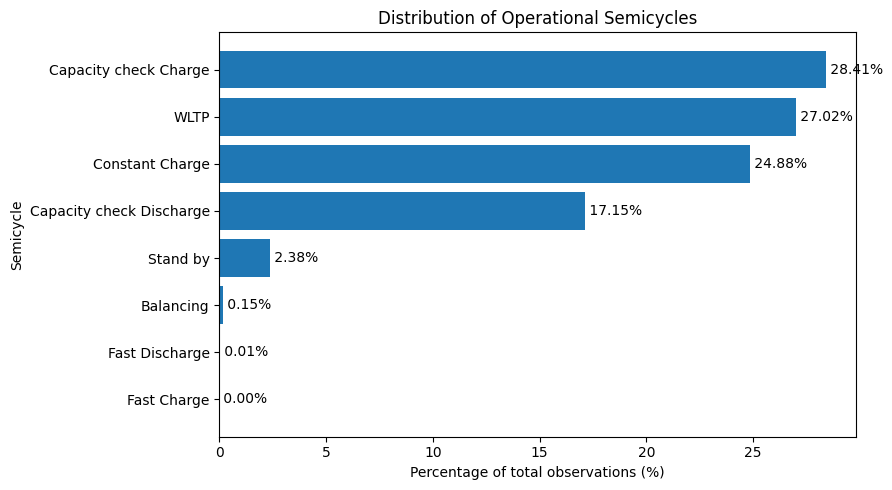

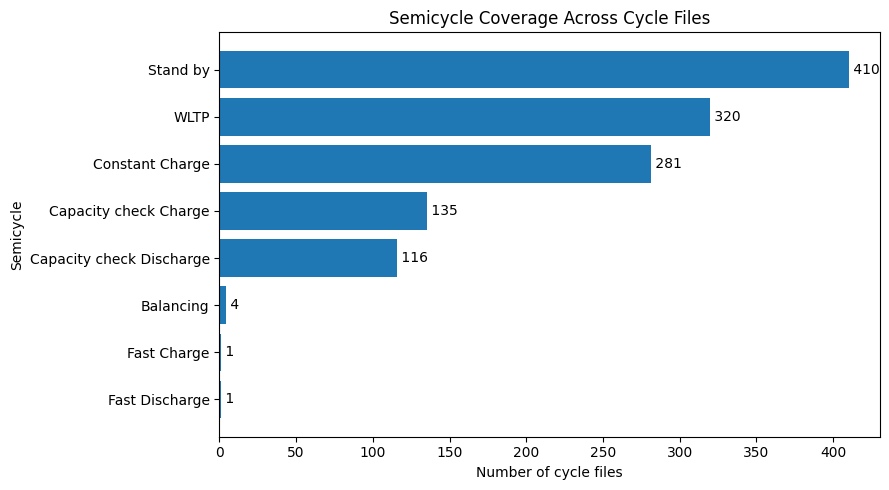

In [16]:
import matplotlib.pyplot as plt

percentage_data = semicycle_summary.sort_values(
    "percentage",
    ascending=True
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    percentage_data["semicycle"],
    percentage_data["percentage"]
)

plt.xlabel("Percentage of total observations (%)")
plt.ylabel("Semicycle")
plt.title("Distribution of Operational Semicycles")

for bar, value in zip(bars, percentage_data["percentage"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

file_data = semicycle_summary.sort_values(
    "files_present",
    ascending=True
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    file_data["semicycle"],
    file_data["files_present"]
)

plt.xlabel("Number of cycle files")
plt.ylabel("Semicycle")
plt.title("Semicycle Coverage Across Cycle Files")

for bar, value in zip(bars, file_data["files_present"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {int(value)}",
        va="center"
    )

plt.tight_layout()
plt.show()

# EDA

## Voltage Behaviour

This section checks cell-voltage differences during WLTP operation.


In [17]:
import numpy as np

# Identify the 36 cell-voltage columns.
cell_voltage_columns = [
    column for column in reference_columns
    if column.startswith("Voltage_Cell_")
]

# Keep all original WLTP files for the coverage check.
wltp_file_names = quality_summary[
    quality_summary["semicycle_types"].apply(
        lambda semicycles: "WLTP" in semicycles
    )
]["file_name"].tolist()

wltp_coverage_records = []

for file_name in wltp_file_names:
    file_path = DATA_DIR / file_name

    # Only timestamp and semicycle are needed for the coverage check.
    coverage_df = pd.read_parquet(
        file_path,
        columns=["Timestamp", "Semicycle"]
    )

    coverage_df = coverage_df[
        coverage_df["Semicycle"] == "WLTP"
    ].copy()

    timestamps = (
        pd.to_datetime(coverage_df["Timestamp"], errors="coerce")
        .dropna()
        .sort_values()
    )

    duration_minutes = np.nan
    median_interval_seconds = np.nan

    # Duration and sampling interval help confirm whether a segment is partial.
    if len(timestamps) >= 2:
        duration_minutes = (
            timestamps.iloc[-1] - timestamps.iloc[0]
        ).total_seconds() / 60

        median_interval_seconds = (
            timestamps.diff()
            .dt.total_seconds()
            .dropna()
            .median()
        )

    cycle_number = int(file_name.split("_")[2])

    wltp_coverage_records.append({
        "cycle": cycle_number,
        "file_name": file_name,
        "observation_count": len(coverage_df),
        "duration_minutes": duration_minutes,
        "median_sampling_interval_seconds": median_interval_seconds
    })

# Create one coverage summary row for each WLTP cycle.
wltp_cycle_coverage = (
    pd.DataFrame(wltp_coverage_records)
    .sort_values("cycle")
    .reset_index(drop=True)
)

# Use a data-driven lower limit instead of choosing a fixed minimum manually.
count_q1 = wltp_cycle_coverage["observation_count"].quantile(0.25)
count_q3 = wltp_cycle_coverage["observation_count"].quantile(0.75)
count_iqr = count_q3 - count_q1
count_lower_tukey_limit = count_q1 - 1.5 * count_iqr

# Identify WLTP segments with unusually low observation coverage.
short_wltp_cycles = wltp_cycle_coverage[
    wltp_cycle_coverage["observation_count"] < count_lower_tukey_limit
].copy()

excluded_short_wltp_cycles = short_wltp_cycles["cycle"].tolist()

excluded_short_wltp_file_names = set(
    short_wltp_cycles["file_name"]
)

retained_wltp_file_names = [
    file_name
    for file_name in wltp_file_names
    if file_name not in excluded_short_wltp_file_names
]

print("Original WLTP segments:", len(wltp_file_names))
print("Observation-count lower Tukey limit:", round(count_lower_tukey_limit, 2))
print("Excluded partial WLTP segments:", excluded_short_wltp_cycles)
print("Retained WLTP segments:", len(retained_wltp_file_names))

print("\nOriginal WLTP coverage medians:")

display(
    wltp_cycle_coverage[
        [
            "observation_count",
            "duration_minutes",
            "median_sampling_interval_seconds"
        ]
    ].median().round(2)
)

print("\nSegments below the observation-count limit:")
display(short_wltp_cycles.round(2))

# Cycle 200 is used only as an illustrative WLTP example.
representative_file_name = next(
    file_name
    for file_name in retained_wltp_file_names
    if int(file_name.split("_")[2]) == 200
)

representative_file = DATA_DIR / representative_file_name

wltp_df = pd.read_parquet(
    representative_file,
    columns=[
        "Timestamp",
        "Semicycle",
        "Current_Actual_Battery [A]",
        "SoC_Actual_Battery [percent]",
        *cell_voltage_columns
    ]
)

wltp_df = wltp_df[
    wltp_df["Semicycle"] == "WLTP"
].copy()

# Calculate the cell-voltage range at each timestamp.
wltp_df["cell_voltage_min"] = wltp_df[cell_voltage_columns].min(axis=1)
wltp_df["cell_voltage_mean"] = wltp_df[cell_voltage_columns].mean(axis=1)
wltp_df["cell_voltage_max"] = wltp_df[cell_voltage_columns].max(axis=1)

wltp_df["cell_voltage_spread"] = (
    wltp_df["cell_voltage_max"]
    - wltp_df["cell_voltage_min"]
)

print("Representative file:", representative_file.name)
print("WLTP observations:", f"{len(wltp_df):,}")

print("\nCell-voltage spread during WLTP [V]:")

display(
    wltp_df["cell_voltage_spread"]
    .describe()
    .round(5)
)

Original WLTP segments: 320
Observation-count lower Tukey limit: 3038.38
Excluded partial WLTP segments: [27, 83, 122, 124, 126]
Retained WLTP segments: 315

Original WLTP coverage medians:


,0
observation_count,25593.50
duration_minutes,161.66
median_sampling_interval_seconds,0.32



Segments below the observation-count limit:


,cycle,file_name,observation_count,duration_minutes,median_sampling_interval_seconds
19,27,Qtzl_Cycle_027_Capacity_check_partial_data.par...,2,0.01,0.40
65,83,Qtzl_Cycle_083_Capacity_check_partial_data.par...,735,4.89,0.40
100,122,Qtzl_Cycle_122_Capacity_check_partial_data.par...,1695,11.29,0.40
101,124,Qtzl_Cycle_124_Capacity_check_partial_data.par...,2332,15.54,0.40
102,126,Qtzl_Cycle_126_Capacity_check.parquet,2,0.01,0.32


Representative file: Qtzl_Cycle_200_WLTP.parquet
WLTP observations: 24,445

Cell-voltage spread during WLTP [V]:


,cell_voltage_spread
count,24445.00000
mean,0.04652
std,0.05113
min,0.00600
25%,0.01700
50%,0.02900
75%,0.06200
max,1.28200


### WLTP Coverage Quality Screening

The lower Tukey IQR limit identified five WLTP segments with insufficient coverage. They were excluded before modelling because they were unusually short, not because they were anomalous. This is a data-quality heuristic rather than a battery threshold.


In [18]:
# Identify the lowest-voltage cell at each timestamp.
wltp_df["min_voltage_cell"] = wltp_df[cell_voltage_columns].idxmin(axis=1)

# Count how often each cell had the lowest voltage during Cycle 200.
lowest_voltage_frequency = (
    wltp_df["min_voltage_cell"]
    .value_counts()
    .rename_axis("cell")
    .reset_index(name="lowest_voltage_count")
)

lowest_voltage_frequency["percentage"] = (
    lowest_voltage_frequency["lowest_voltage_count"]
    / len(wltp_df)
    * 100
)

display(
    lowest_voltage_frequency
    .head(15)
    .round({"percentage": 2})
)

,cell,lowest_voltage_count,percentage
0,Voltage_Cell_P1S6 [V],20204,82.65
1,Voltage_Cell_P1S12 [V],1727,7.06
2,Voltage_Cell_P2S12 [V],1359,5.56
3,Voltage_Cell_P3S6 [V],443,1.81
4,Voltage_Cell_P1S1 [V],281,1.15
5,Voltage_Cell_P2S6 [V],170,0.70
6,Voltage_Cell_P3S12 [V],113,0.46
7,Voltage_Cell_P1S5 [V],46,0.19
8,Voltage_Cell_P3S1 [V],22,0.09
9,Voltage_Cell_P2S4 [V],19,0.08


In [19]:
# Find the dominant lowest-voltage cell in each WLTP cycle.
wltp_lowest_cell_records = []

for file_path in parquet_files:

    if file_path.name not in retained_wltp_file_names:
        continue

    df = pd.read_parquet(
        file_path,
        columns=["Semicycle", *cell_voltage_columns]
    )

    wltp_data = df[df["Semicycle"] == "WLTP"]

    if len(wltp_data) == 0:
        continue

    lowest_cell = wltp_data[cell_voltage_columns].idxmin(axis=1)
    counts = lowest_cell.value_counts()

    most_frequent_cell = counts.index[0]
    most_frequent_count = counts.iloc[0]

    cycle_number = int(
        quality_summary.loc[
            quality_summary["file_name"] == file_path.name,
            "expected_cycle"
        ].iloc[0]
    )

    wltp_lowest_cell_records.append({
        "cycle": cycle_number,
        "lowest_voltage_cell": most_frequent_cell,
        "count": int(most_frequent_count),
        "percentage": most_frequent_count / len(wltp_data) * 100
    })

wltp_lowest_cell_summary = (
    pd.DataFrame(wltp_lowest_cell_records)
    .sort_values("cycle")
    .reset_index(drop=True)
)

display(
    wltp_lowest_cell_summary
    .head(20)
    .round({"percentage": 2})
)

,cycle,lowest_voltage_cell,count,percentage
0,2,Voltage_Cell_P1S12 [V],4030,42.74
1,3,Voltage_Cell_P1S4 [V],5068,14.76
2,4,Voltage_Cell_P2S3 [V],5829,18.76
3,5,Voltage_Cell_P3S12 [V],8301,29.09
4,6,Voltage_Cell_P1S6 [V],5531,19.71
5,7,Voltage_Cell_P2S9 [V],5160,17.23
6,8,Voltage_Cell_P1S11 [V],5098,17.74
7,9,Voltage_Cell_P2S9 [V],4272,13.69
8,10,Voltage_Cell_P3S12 [V],5735,19.23
9,11,Voltage_Cell_P2S9 [V],5659,17.51


In [20]:
dominant_cell_summary = (
    wltp_lowest_cell_summary["lowest_voltage_cell"]
    .value_counts()
    .rename_axis("cell")
    .reset_index(name="dominant_cycle_count")
)

dominant_cell_summary["percentage_of_wltp_cycles"] = (
    dominant_cell_summary["dominant_cycle_count"]
    / len(wltp_lowest_cell_summary)
    * 100
)

display(
    dominant_cell_summary
    .head(15)
    .round({"percentage_of_wltp_cycles": 2})
)

,cell,dominant_cycle_count,percentage_of_wltp_cycles
0,Voltage_Cell_P1S6 [V],213,67.62
1,Voltage_Cell_P2S9 [V],56,17.78
2,Voltage_Cell_P2S8 [V],19,6.03
3,Voltage_Cell_P2S6 [V],8,2.54
4,Voltage_Cell_P3S12 [V],4,1.27
5,Voltage_Cell_P1S12 [V],3,0.95
6,Voltage_Cell_P3S6 [V],3,0.95
7,Voltage_Cell_P1S11 [V],2,0.63
8,Voltage_Cell_P2S3 [V],1,0.32
9,Voltage_Cell_P1S4 [V],1,0.32


P1S6 was repeatedly the dominant lowest-voltage cell across the retained cycles. This describes relative voltage behaviour, not a physical fault.


## Temperature Behaviour

Check temperature patterns and identify unreliable sensor readings.

In [21]:
cell_ids = [
    f"P{branch}S{series}"
    for branch in range(1, 4)
    for series in range(1, 13)
]

wltp_temperature_df = pd.read_parquet(
    representative_file,
    columns=["Semicycle", *cell_temperature_columns]
)

wltp_temperature_df = wltp_temperature_df[
    wltp_temperature_df["Semicycle"] == "WLTP"
].copy()

# Average the top and bottom sensors for each cell.
cell_average_temperature_columns = []

for cell in cell_ids:

    new_column = f"Temperature_{cell}"

    wltp_temperature_df[new_column] = (
        wltp_temperature_df[
            [
                f"Temperature_Cell_Top_{cell} [degC]",
                f"Temperature_Cell_Bottom_{cell} [degC]"
            ]
        ].mean(axis=1)
    )

    cell_average_temperature_columns.append(new_column)

wltp_temperature_df["cell_temperature_min"] = (
    wltp_temperature_df[cell_average_temperature_columns].min(axis=1)
)

wltp_temperature_df["cell_temperature_mean"] = (
    wltp_temperature_df[cell_average_temperature_columns].mean(axis=1)
)

wltp_temperature_df["cell_temperature_max"] = (
    wltp_temperature_df[cell_average_temperature_columns].max(axis=1)
)

wltp_temperature_df["cell_temperature_spread"] = (
    wltp_temperature_df["cell_temperature_max"]
    - wltp_temperature_df["cell_temperature_min"]
)

print("WLTP observations:", f"{len(wltp_temperature_df):,}")

print("\nCell-temperature spread during WLTP [degC]:")
display(
    wltp_temperature_df["cell_temperature_spread"]
    .describe()
    .round(3)
)

WLTP observations: 24,445

Cell-temperature spread during WLTP [degC]:


,cell_temperature_spread
count,24445.000
mean,326.872
std,290.844
min,31.770
25%,33.105
50%,310.300
75%,635.410
max,639.050


In [22]:
# Check temperature ranges across all cycles.
global_temperature_min = {
    column: float("inf")
    for column in cell_temperature_columns
}

global_temperature_max = {
    column: float("-inf")
    for column in cell_temperature_columns
}

for file_path in parquet_files:

    df = pd.read_parquet(
        file_path,
        columns=cell_temperature_columns
    )

    file_min = df.min()
    file_max = df.max()

    for column in cell_temperature_columns:
        global_temperature_min[column] = min(
            global_temperature_min[column],
            file_min[column]
        )

        global_temperature_max[column] = max(
            global_temperature_max[column],
            file_max[column]
        )

temperature_sensor_summary = pd.DataFrame({
    "global_min": global_temperature_min,
    "global_max": global_temperature_max
})

print("Highest temperature ranges:")
display(
    temperature_sensor_summary
    .sort_values("global_max", ascending=False)
    .head(15)
    .round(2)
)

print("\nLowest temperature ranges:")
display(
    temperature_sensor_summary
    .sort_values("global_min")
    .head(15)
    .round(2)
)

Highest temperature ranges:


,global_min,global_max
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Bottom_P2S6 [degC],22.650000,382.209991
Temperature_Cell_Top_P2S6 [degC],21.420000,382.209991
Temperature_Cell_Bottom_P2S5 [degC],22.129999,382.209991
Temperature_Cell_Top_P2S5 [degC],22.299999,382.209991
Temperature_Cell_Bottom_P2S10 [degC],22.830000,153.759995
Temperature_Cell_Bottom_P3S2 [degC],22.260000,43.570000



Lowest temperature ranges:


,global_min,global_max
Temperature_Cell_Bottom_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P1S2 [degC],18.730000,42.500000
Temperature_Cell_Bottom_P1S4 [degC],18.740000,42.509998
Temperature_Cell_Top_P2S11 [degC],18.959999,39.840000
Temperature_Cell_Bottom_P1S3 [degC],19.530001,42.619999
Temperature_Cell_Top_P1S6 [degC],19.590000,42.029999
Temperature_Cell_Bottom_P1S6 [degC],20.030001,41.369999


### Temperature Screening Range Explanation

Values outside 5–80°C are screened as unreliable measurements. The 5°C lower limit follows the reported chamber range, while the higher upper limit allows for additional heating during operation.


In [23]:
# Dataset-specific screening range: 5–80°C.
suspicious_temperature_sensors = temperature_sensor_summary[
    (temperature_sensor_summary["global_min"] < 5)
    | (temperature_sensor_summary["global_max"] > 80)
].copy()

display(
    suspicious_temperature_sensors
    .sort_values("global_max", ascending=False)
    .round(2)
)

print("Suspicious temperature sensors:", len(suspicious_temperature_sensors))

,global_min,global_max
Temperature_Cell_Top_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Bottom_P3S11 [degC],0.050000,655.309998
Temperature_Cell_Top_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Bottom_P1S5 [degC],0.030000,655.280029
Temperature_Cell_Top_P2S5 [degC],22.299999,382.209991
Temperature_Cell_Top_P2S6 [degC],21.420000,382.209991
Temperature_Cell_Bottom_P2S5 [degC],22.129999,382.209991
Temperature_Cell_Bottom_P2S6 [degC],22.650000,382.209991
Temperature_Cell_Bottom_P2S10 [degC],22.830000,153.759995


Suspicious temperature sensors: 9


In [24]:
# Count invalid readings for each suspicious sensor.
temperature_issue_records = []

for file_path in parquet_files:

    df = pd.read_parquet(
        file_path,
        columns=suspicious_temperature_sensors.index.tolist()
    )

    for column in suspicious_temperature_sensors.index:

        invalid_count = (
            (df[column] < 5)
            | (df[column] > 80)
        ).sum()

        temperature_issue_records.append({
            "sensor": column,
            "total_rows": len(df),
            "invalid_rows": int(invalid_count)
        })

temperature_issue_summary = (
    pd.DataFrame(temperature_issue_records)
    .groupby("sensor", as_index=False)
    .sum()
)

temperature_issue_summary["invalid_percentage"] = (
    temperature_issue_summary["invalid_rows"]
    / temperature_issue_summary["total_rows"]
    * 100
)

display(
    temperature_issue_summary
    .sort_values("invalid_percentage", ascending=False)
    .round({"invalid_percentage": 2})
)

,sensor,total_rows,invalid_rows,invalid_percentage
8,Temperature_Cell_Top_P3S11 [degC],30187165,30122426,99.79
4,Temperature_Cell_Bottom_P3S11 [degC],30187165,30117883,99.77
5,Temperature_Cell_Top_P1S5 [degC],30187165,8630774,28.59
0,Temperature_Cell_Bottom_P1S5 [degC],30187165,8190548,27.13
2,Temperature_Cell_Bottom_P2S5 [degC],30187165,433,0.00
6,Temperature_Cell_Top_P2S5 [degC],30187165,433,0.00
3,Temperature_Cell_Bottom_P2S6 [degC],30187165,433,0.00
7,Temperature_Cell_Top_P2S6 [degC],30187165,433,0.00
1,Temperature_Cell_Bottom_P2S10 [degC],30187165,66,0.00


### Temperature Cleaning

P1S5 and P3S11 are excluded because their temperature measurements are unreliable. The same 34-cell population is then kept across Experiments A, B and C for a fair comparison.

In [25]:
clean_temperature_df = wltp_temperature_df.copy()

# Mask values outside 5–80°C.
clean_temperature_df[cell_temperature_columns] = (
    clean_temperature_df[cell_temperature_columns]
    .mask(
        (clean_temperature_df[cell_temperature_columns] < 5)
        | (clean_temperature_df[cell_temperature_columns] > 80)
    )
)

print("Cleaned temperature data created.")

Cleaned temperature data created.


In [26]:
# Exclude cells with persistent temperature sensor issues.
reliable_temperature_cells = [
    cell for cell in cell_ids
    if cell not in ["P1S5", "P3S11"]
]

clean_temperature_columns = {
    f"Clean_Temperature_{cell}": (
        clean_temperature_df[
            [
                f"Temperature_Cell_Top_{cell} [degC]",
                f"Temperature_Cell_Bottom_{cell} [degC]"
            ]
        ].mean(axis=1)
    )
    for cell in reliable_temperature_cells
}

clean_temperature_df = pd.concat(
    [
        clean_temperature_df,
        pd.DataFrame(
            clean_temperature_columns,
            index=clean_temperature_df.index
        )
    ],
    axis=1
)

reliable_temperature_columns = list(clean_temperature_columns.keys())

clean_temperature_df["temperature_min"] = (
    clean_temperature_df[reliable_temperature_columns].min(axis=1)
)

clean_temperature_df["temperature_mean"] = (
    clean_temperature_df[reliable_temperature_columns].mean(axis=1)
)

clean_temperature_df["temperature_max"] = (
    clean_temperature_df[reliable_temperature_columns].max(axis=1)
)

clean_temperature_df["temperature_spread"] = (
    clean_temperature_df["temperature_max"]
    - clean_temperature_df["temperature_min"]
)

print("Cleaned cell-temperature spread during WLTP:")

display(
    clean_temperature_df["temperature_spread"]
    .describe()
    .round(3)
)

Cleaned cell-temperature spread during WLTP:


,temperature_spread
count,24445.000
mean,3.464
std,0.468
min,2.500
25%,3.175
50%,3.470
75%,3.720
max,6.270


### Sensor Investigation

P1S5 is checked across WLTP cycles to assess whether its unusual temperature measurements persist.


In [27]:
p1s5_relative_records = []

p1s5_comparison_cells = [
    cell for cell in cell_ids
    if cell != "P3S11"
]

for file_name in retained_wltp_file_names:

    file_path = DATA_DIR / file_name

    df = pd.read_parquet(
        file_path,
        columns=["Semicycle", *cell_temperature_columns]
    )

    df = df[df["Semicycle"] == "WLTP"].copy()

    if len(df) == 0:
        continue

    # Mask implausible temperature values.
    temperature_data = df[cell_temperature_columns].mask(
        (df[cell_temperature_columns] < 5)
        | (df[cell_temperature_columns] > 80)
    )

    cell_temperatures = {}

    for cell in p1s5_comparison_cells:

        cell_temperatures[cell] = temperature_data[
            [
                f"Temperature_Cell_Top_{cell} [degC]",
                f"Temperature_Cell_Bottom_{cell} [degC]"
            ]
        ].mean(axis=1)

    cell_temperature_df = pd.DataFrame(cell_temperatures)

    p1s5_median = cell_temperature_df["P1S5"].median()

    other_cells_median = (
        cell_temperature_df
        .drop(columns="P1S5")
        .median(axis=1)
        .median()
    )

    p1s5_relative_records.append({
        "file": file_name,
        "P1S5_median": p1s5_median,
        "other_cells_median": other_cells_median,
        "difference": p1s5_median - other_cells_median
    })

p1s5_relative_summary = pd.DataFrame(p1s5_relative_records)

display(
    p1s5_relative_summary["difference"]
    .describe()
    .round(2)
)

print("\nCycles with the largest negative P1S5 temperature difference:")

display(
    p1s5_relative_summary
    .sort_values("difference")
    .head(10)
    .round(2)
)

,difference
count,294.00
mean,-8.14
std,9.16
min,-27.51
25%,-18.06
50%,-2.60
75%,-0.58
max,2.31



Cycles with the largest negative P1S5 temperature difference:


,file,P1S5_median,other_cells_median,difference
266,Qtzl_Cycle_348_WLTP.parquet,5.59,33.10,-27.51
261,Qtzl_Cycle_339_WLTP.parquet,6.40,33.17,-26.76
253,Qtzl_Cycle_329_WLTP.parquet,5.93,32.40,-26.47
138,Qtzl_Cycle_179_WLTP.parquet,5.88,31.29,-25.41
200,Qtzl_Cycle_262_WLTP.parquet,6.07,30.77,-24.70
241,Qtzl_Cycle_315_WLTP.parquet,6.07,30.15,-24.08
267,Qtzl_Cycle_349_WLTP.parquet,5.49,29.28,-23.79
175,Qtzl_Cycle_226_WLTP.parquet,6.69,30.42,-23.73
120,Qtzl_Cycle_153_WLTP.parquet,5.40,28.92,-23.52
288,Qtzl_Cycle_376_WLTP.parquet,5.64,28.92,-23.28


## Operating Conditions

Cycle 200 is an illustrative example only. Dataset-level conclusions use Spearman correlations calculated across all 315 retained WLTP cycles. Absolute current represents load intensity, regardless of current direction.

Absolute current had a more consistent positive association with cell-voltage spread than SoC. Correlation does not establish causation.


In [28]:
from scipy.stats import spearmanr


def safe_spearman(first, second):
    pair = pd.concat([first, second], axis=1).dropna()

    # Skip correlations with too few valid values or no variation.
    if len(pair) < 3:
        return np.nan

    if pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan

    return float(
        spearmanr(
            pair.iloc[:, 0],
            pair.iloc[:, 1]
        ).statistic
    )


cycle_correlation_records = []

for file_name in retained_wltp_file_names:

    cycle_df = pd.read_parquet(
        DATA_DIR / file_name,
        columns=[
            "Semicycle",
            "Current_Actual_Battery [A]",
            "SoC_Actual_Battery [percent]",
            *cell_voltage_columns
        ]
    )

    cycle_df = cycle_df[
        cycle_df["Semicycle"] == "WLTP"
    ].copy()

    voltage_spread = (
        cycle_df[cell_voltage_columns].max(axis=1)
        - cycle_df[cell_voltage_columns].min(axis=1)
    )

    absolute_current = cycle_df["Current_Actual_Battery [A]"].abs()
    soc = cycle_df["SoC_Actual_Battery [percent]"]

    cycle_correlation_records.append({
        "cycle": int(file_name.split("_")[2]),
        "current_spread_correlation": safe_spearman(
            absolute_current,
            voltage_spread
        ),
        "soc_spread_correlation": safe_spearman(
            soc,
            voltage_spread
        )
    })

cycle_correlations = pd.DataFrame(cycle_correlation_records)


def summarise_correlations(series):
    valid = series.dropna()

    positive = int((valid > 0).sum())
    negative = int((valid < 0).sum())

    return pd.Series({
        "valid_cycles": len(valid),
        "mean": valid.mean(),
        "median": valid.median(),
        "Q1": valid.quantile(0.25),
        "Q3": valid.quantile(0.75),
        "minimum": valid.min(),
        "maximum": valid.max(),
        "positive_cycles": positive,
        "positive_percent": positive / len(valid) * 100 if len(valid) else np.nan,
        "negative_cycles": negative,
        "negative_percent": negative / len(valid) * 100 if len(valid) else np.nan
    })


cycle_correlation_summary = pd.DataFrame({
    "absolute_current_vs_spread": summarise_correlations(
        cycle_correlations["current_spread_correlation"]
    ),
    "soc_vs_spread": summarise_correlations(
        cycle_correlations["soc_spread_correlation"]
    )
}).T

display(cycle_correlation_summary.round(3))

current_median = cycle_correlation_summary.loc[
    "absolute_current_vs_spread",
    "median"
]

soc_median = cycle_correlation_summary.loc[
    "soc_vs_spread",
    "median"
]

print("\nDataset-wide conclusion:")

print(
    "The median absolute-current relationship is "
    f"{current_median:.3f}, and the median SoC relationship is {soc_median:.3f}. "
    "These values describe association, not causation."
)

,valid_cycles,mean,median,Q1,Q3,minimum,maximum,positive_cycles,positive_percent,negative_cycles,negative_percent
absolute_current_vs_spread,315.0,0.681,0.83,0.510,0.876,-0.972,0.907,308.0,97.778,7.0,2.222
soc_vs_spread,306.0,-0.170,-0.05,-0.419,0.028,-0.833,0.461,104.0,33.987,202.0,66.013



Dataset-wide conclusion:
The median absolute-current relationship is 0.830, and the median SoC relationship is -0.050. These values describe association, not causation.


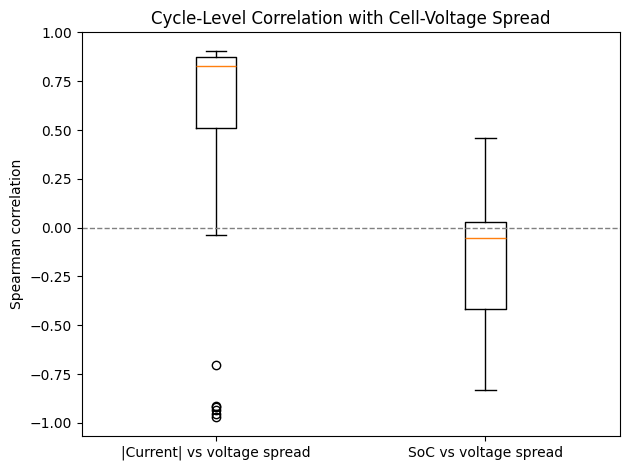

In [29]:
correlation_plot_data = [
    cycle_correlations["current_spread_correlation"].dropna(),
    cycle_correlations["soc_spread_correlation"].dropna()
]

plt.boxplot(
    correlation_plot_data,
    tick_labels=["|Current| vs voltage spread", "SoC vs voltage spread"]
)
plt.axhline(0, color="grey", linewidth=1, linestyle="--")
plt.ylabel("Spearman correlation")
plt.title("Cycle-Level Correlation with Cell-Voltage Spread")
plt.tight_layout()
plt.show()


In [30]:
# Save outputs required by the next notebook.
import pickle

data_preparation_outputs = {
    "DATA_DIR": DATA_DIR,
    "quality_summary": quality_summary,
    "wltp_file_names": wltp_file_names,
    "retained_wltp_file_names": retained_wltp_file_names,
    "wltp_cycle_coverage": wltp_cycle_coverage,
    "cell_voltage_columns": cell_voltage_columns,
    "cell_temperature_columns": cell_temperature_columns,
    "cell_ids": cell_ids,
    "reliable_temperature_cells": reliable_temperature_cells,
}

with open(DATA_DIR / "data_preparation_outputs.pkl", "wb") as file:
    pickle.dump(data_preparation_outputs, file)

print("Saved:", DATA_DIR / "data_preparation_outputs.pkl")

Saved: /content/data_preparation_outputs.pkl
